In [38]:
#importing all libraries i used in this project
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

In [39]:
data=pd.read_csv('D:\\doc\\OneDrive\\Desktop\\MSC PROJECT\\data_with_diseases.csv')

In [40]:
data

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 41,Diabetes,Hypertension,Infertility,stressLevel
0,1,1,0,28,44.6,152.000,19.300000,15,78,22,...,3,3,18.0,18.0,8.5,NaN,0,0,0,1
1,2,2,0,36,65.0,161.500,24.921163,15,74,20,...,3,5,15.0,14.0,3.7,NaN,0,0,0,2
2,3,3,1,33,68.8,165.000,25.270891,11,72,18,...,13,15,18.0,20.0,10.0,NaN,1,1,0,3
3,4,4,0,37,65.0,148.000,29.674945,13,72,20,...,2,2,15.0,14.0,7.5,NaN,0,0,0,2
4,5,5,0,25,52.0,161.000,20.060954,11,72,18,...,3,4,16.0,14.0,7.0,NaN,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,537,537,0,35,50.0,164.592,18.500000,17,72,16,...,1,0,17.5,10.0,6.7,NaN,0,0,0,1
537,538,538,0,30,63.2,158.000,25.300000,15,72,18,...,9,7,19.0,18.0,8.2,NaN,0,0,0,2
538,539,539,0,36,54.0,152.000,23.400000,13,74,20,...,1,0,18.0,9.0,7.3,NaN,0,0,0,2
539,540,540,0,27,50.0,150.000,22.200000,15,74,20,...,7,6,18.0,16.0,11.5,NaN,0,0,0,1


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

<Axes: >

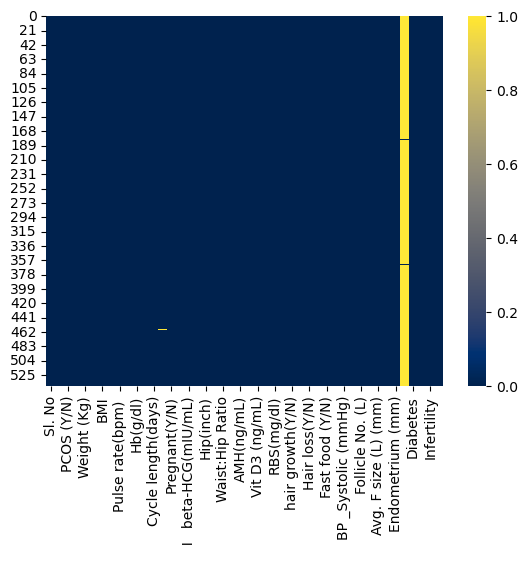

In [42]:
sns.heatmap(data.isnull(), cmap="cividis")

In [43]:
data.drop(["Marraige Status (Yrs)","Fast food (Y/N)","Unnamed: 41","Sl. No","Patient File No."],axis=1,inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int64  
 1    Age (yrs)              541 non-null    int64  
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    int64  
 6   Pulse rate(bpm)         541 non-null    int64  
 7   RR (breaths/min)        541 non-null    int64  
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    int64  
 10  Cycle length(days)      541 non-null    int64  
 11  Pregnant(Y/N)           541 non-null    int64  
 12  No. of aborptions       541 non-null    int64  
 13    I   beta-HCG(mIU/mL)  541 non-null    float64
 14  II    beta-HCG(mIU/mL)  541 non-null    fl

In [44]:
data.isnull().sum()

PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
BMI                       0
Blood Group               0
Pulse rate(bpm)           0
RR (breaths/min)          0
Hb(g/dl)                  0
Cycle(R/I)                0
Cycle length(days)        0
Pregnant(Y/N)             0
No. of aborptions         0
  I   beta-HCG(mIU/mL)    0
II    beta-HCG(mIU/mL)    0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
TSH (mIU/L)               0
AMH(ng/mL)                0
PRL(ng/mL)                0
Vit D3 (ng/mL)            0
PRG(ng/mL)                0
RBS(mg/dl)                0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Reg.Exercise(Y/N)         0
BP _Systolic (mmHg)       0
BP _Diastolic (mmHg)      0
Follicle No. (L)          0
Follicle No. (R)          0
Avg. F size (L) (mm)      0
Avg. F size (R) (mm)

<Axes: >

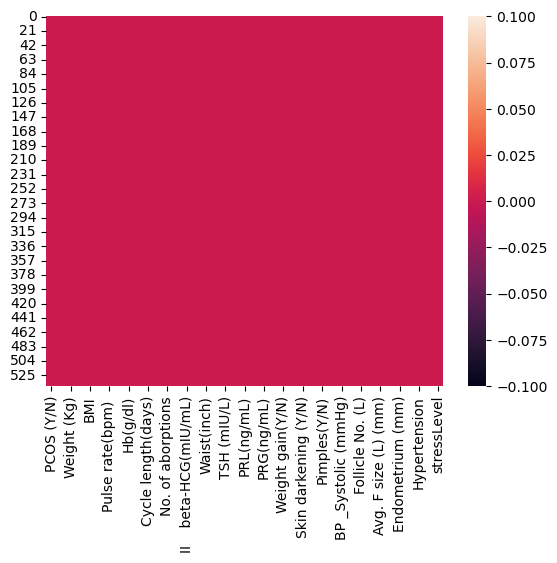

In [45]:
sns.heatmap(data.isnull())

<Axes: xlabel='PCOS (Y/N)'>

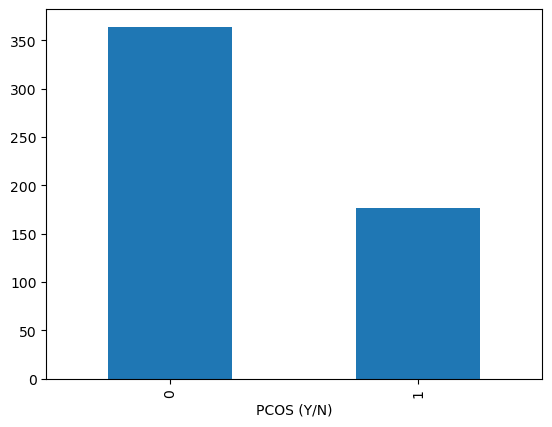

In [46]:
data["PCOS (Y/N)"].value_counts().plot(kind="bar")

In [47]:
for col in data.select_dtypes(include='int64'):
    data[col]=data[col].astype(float)

In [48]:
data["AMH(ng/mL)"] = pd.to_numeric(data["AMH(ng/mL)"], errors='coerce')
data.fillna({'AMH(ng/mL)' : data['AMH(ng/mL)'].median()} , inplace = True)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    float64
 1    Age (yrs)              541 non-null    float64
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    float64
 6   Pulse rate(bpm)         541 non-null    float64
 7   RR (breaths/min)        541 non-null    float64
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    float64
 10  Cycle length(days)      541 non-null    float64
 11  Pregnant(Y/N)           541 non-null    float64
 12  No. of aborptions       541 non-null    float64
 13    I   beta-HCG(mIU/mL)  541 non-null    float64
 14  II    beta-HCG(mIU/mL)  541 non-null    fl

In [50]:
data['PCOS (Y/N)'] = data['PCOS (Y/N)'].astype(int)

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int32  
 1    Age (yrs)              541 non-null    float64
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    float64
 6   Pulse rate(bpm)         541 non-null    float64
 7   RR (breaths/min)        541 non-null    float64
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    float64
 10  Cycle length(days)      541 non-null    float64
 11  Pregnant(Y/N)           541 non-null    float64
 12  No. of aborptions       541 non-null    float64
 13    I   beta-HCG(mIU/mL)  541 non-null    float64
 14  II    beta-HCG(mIU/mL)  541 non-null    fl

## Split The Data

In [52]:
y=data["PCOS (Y/N)"]

In [53]:
x=data.drop(["PCOS (Y/N)"],axis=1)

In [54]:
x

,Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),...,BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Diabetes,Hypertension,Infertility,stressLevel
0,28.0,44.6,152.000,19.300000,15.0,78.0,22.0,10.48,2.0,5.0,...,80.0,3.0,3.0,18.0,18.0,8.5,0.0,0.0,0.0,1.0
1,36.0,65.0,161.500,24.921163,15.0,74.0,20.0,11.70,2.0,5.0,...,70.0,3.0,5.0,15.0,14.0,3.7,0.0,0.0,0.0,2.0
2,33.0,68.8,165.000,25.270891,11.0,72.0,18.0,11.80,2.0,5.0,...,80.0,13.0,15.0,18.0,20.0,10.0,1.0,1.0,0.0,3.0
3,37.0,65.0,148.000,29.674945,13.0,72.0,20.0,12.00,2.0,5.0,...,70.0,2.0,2.0,15.0,14.0,7.5,0.0,0.0,0.0,2.0
4,25.0,52.0,161.000,20.060954,11.0,72.0,18.0,10.00,2.0,5.0,...,80.0,3.0,4.0,16.0,14.0,7.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,35.0,50.0,164.592,18.500000,17.0,72.0,16.0,11.00,2.0,5.0,...,70.0,1.0,0.0,17.5,10.0,6.7,0.0,0.0,0.0,1.0
537,30.0,63.2,158.000,25.300000,15.0,72.0,18.0,10.80,2.0,5.0,...,70.0,9.0,7.0,19.0,18.0,8.2,0.0,0.0,0.0,2.0
538,36.0,54.0,152.000,23.400000,13.0,74.0,20.0,10.80,2.0,6.0,...,80.0,1.0,0.0,18.0,9.0,7.3,0.0,0.0,0.0,2.0
539,27.0,50.0,150.000,22.200000,15.0,74.0,20.0,12.00,4.0,2.0,...,70.0,7.0,6.0,18.0,16.0,11.5,0.0,0.0,0.0,1.0


In [55]:
y

0      0
1      0
2      1
3      0
4      0
      ..
536    0
537    0
538    0
539    0
540    1
Name: PCOS (Y/N), Length: 541, dtype: int32

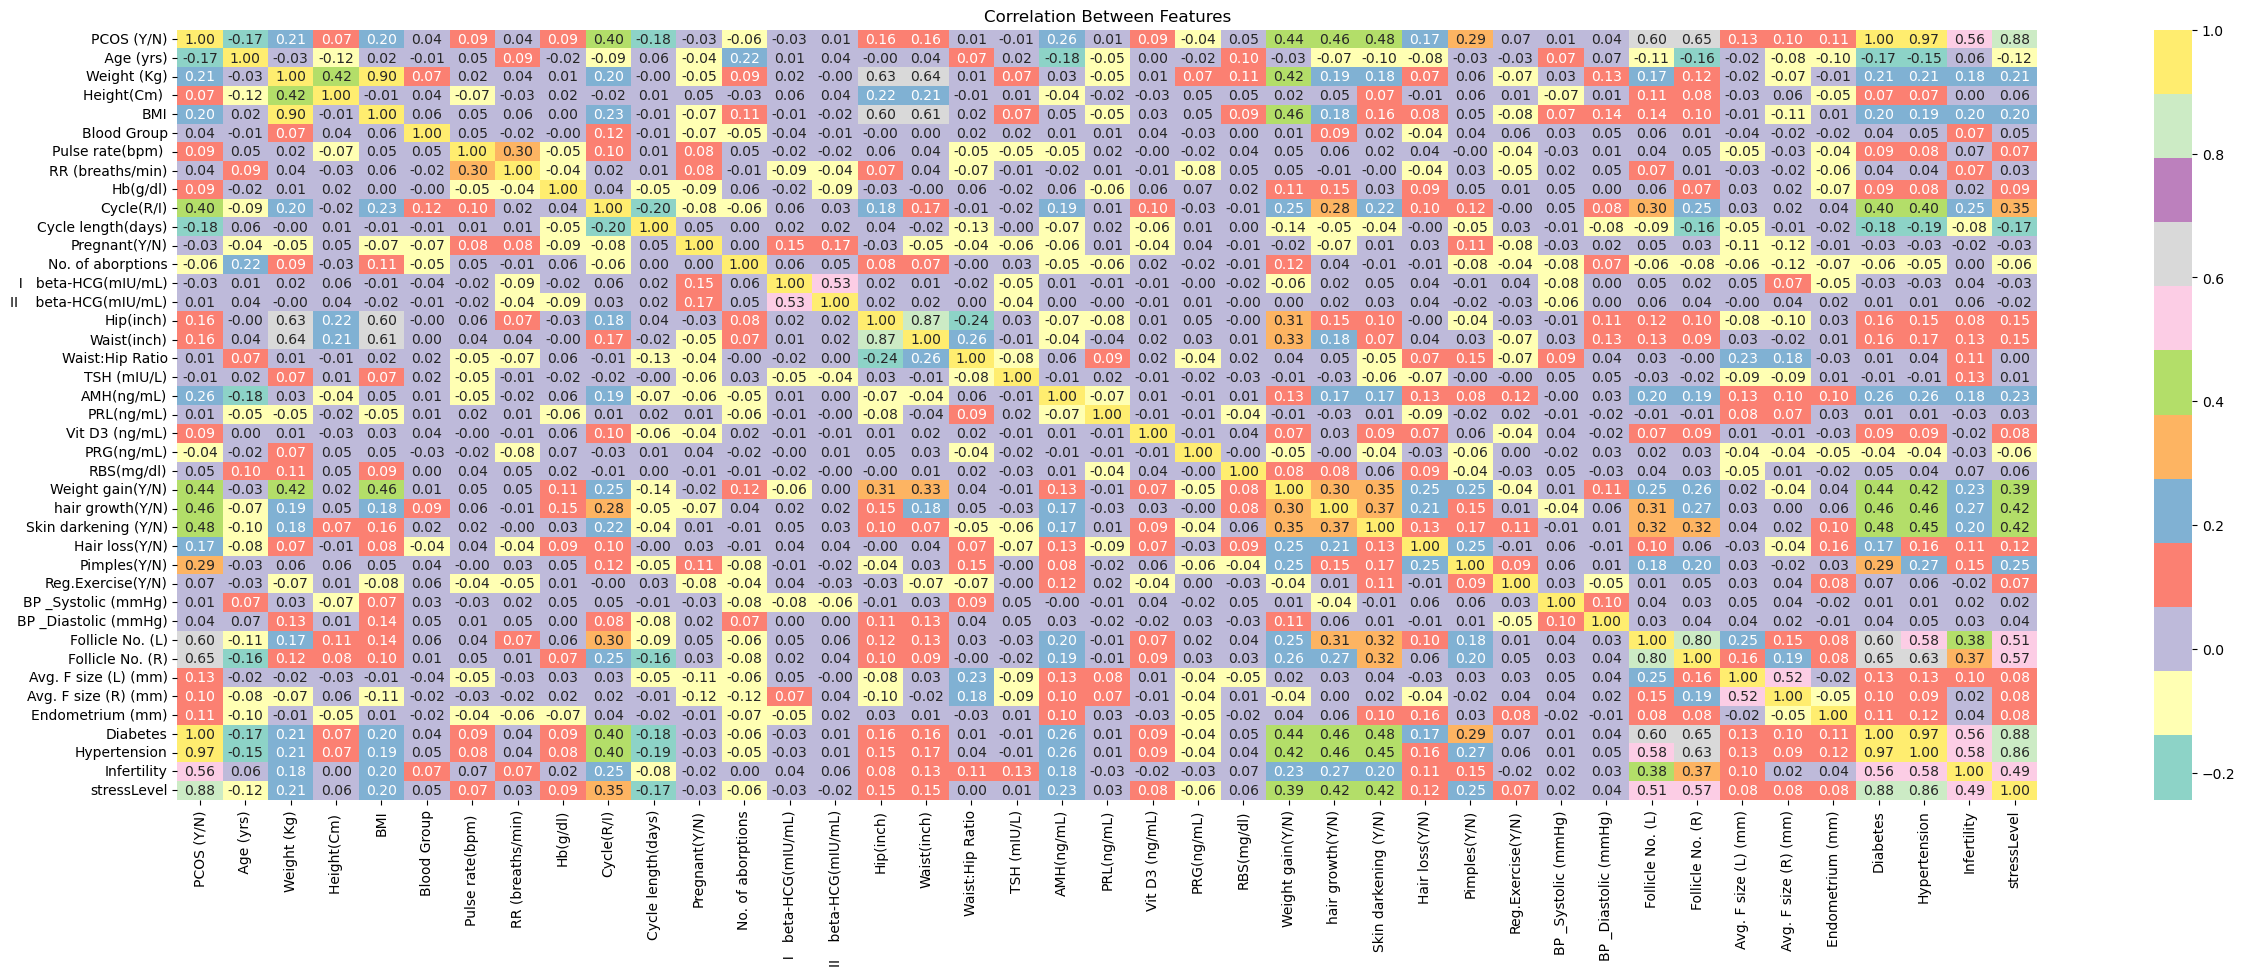

In [56]:
corr_matrix= data.corr(method = 'pearson')
plt.subplots(figsize=(30,10))
sns.heatmap(corr_matrix,cmap="Set3", annot = True, fmt = ".2f");
plt.title("Correlation Between Features")
plt.show()

In [57]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.30,
random_state = 42)

In [58]:
print("X_train",len(x_train))
print("X_test",len(x_test))
print("y_train",len(y_train))
print("y_test",len(y_test))

X_train 378
X_test 163
y_train 378
y_test 163


## Import logistic regression

In [59]:
lr=LogisticRegression()

In [60]:
lr.fit(x_train,y_train)
acclogtrain=round(lr.score(x_train,y_train)*100,2)
acclogtest=round(lr.score(x_test,y_test)*100,2)
print("Training Accuracy:",acclogtrain,"%")
print("Testing Accuracy:",acclogtest,"%")

Training Accuracy: 93.39 %
Testing Accuracy: 88.96 %


In [65]:
y_prediction_values=lr.predict(x_test)

In [66]:
y_prediction_values

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0])

In [67]:
y_test

229    0
73     0
352    1
86     0
470    1
      ..
275    1
362    0
31     1
113    1
381    0
Name: PCOS (Y/N), Length: 163, dtype: int32

## Checking Accuracy

In [68]:
accuracy = accuracy_score(y_test,y_prediction_values)
print(f"Accuracy: {accuracy: 2f}")

Accuracy:  0.889571


In [69]:
print(classification_report(y_test,y_prediction_values))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       110
           1       0.87      0.77      0.82        53

    accuracy                           0.89       163
   macro avg       0.88      0.86      0.87       163
weighted avg       0.89      0.89      0.89       163



In [70]:
y_prob = lr.predict_proba(x_test)
print("Predicted probabilities:", y_prob[:5])

Predicted probabilities: [[0.86523911 0.13476089]
 [0.97375912 0.02624088]
 [0.90946293 0.09053707]
 [0.54958273 0.45041727]
 [0.29140478 0.70859522]]


<Axes: >

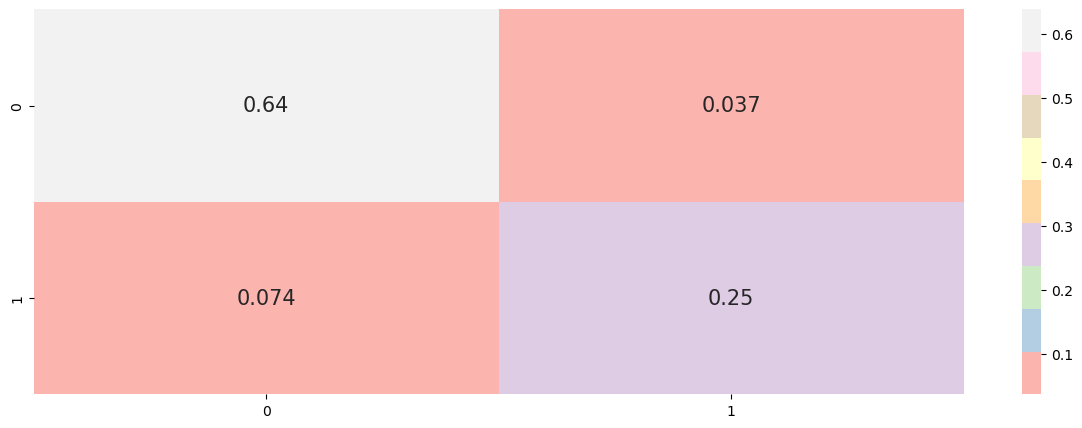

In [71]:
from sklearn.metrics import confusion_matrix
plt.subplots(figsize=(15,5))
cf_matrix = confusion_matrix(y_test, y_prediction_values)
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot = True, annot_kws ={'size':15}, cmap = 'Pastel1')

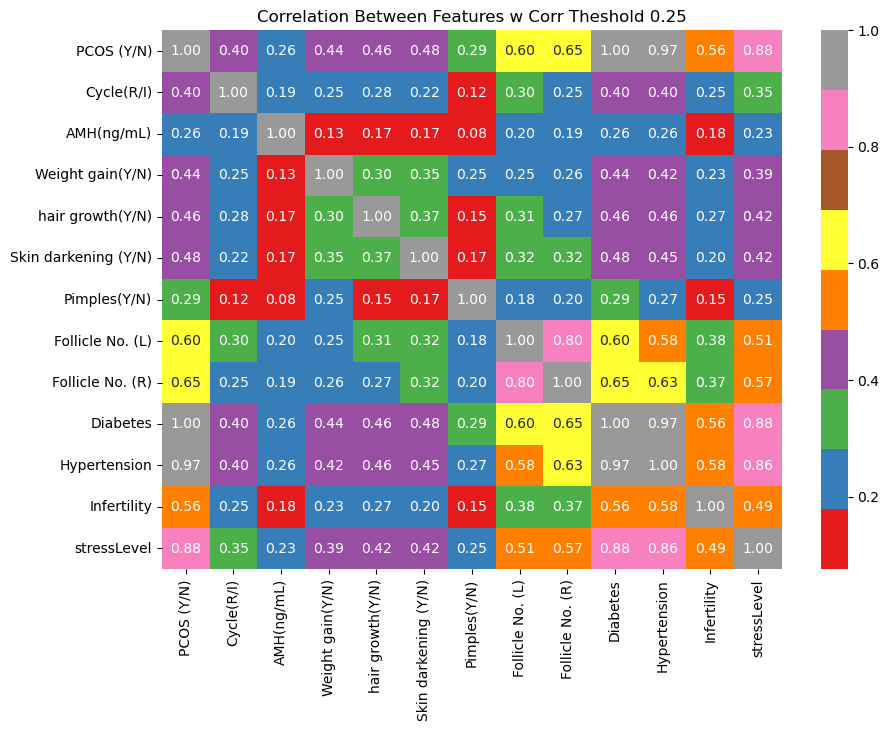

In [72]:
threshold = 0.25
filtre = np.abs(corr_matrix["PCOS (Y/N)"]) > threshold
corr_features = corr_matrix.columns[filtre].tolist()
plt.subplots(figsize=(10,7))
sns.heatmap(data[corr_features].corr(),cmap="Set1", annot = True, fmt = ".2f")
plt.title("Correlation Between Features w Corr Theshold 0.25")
plt.show()

## Prediction for new inputs of independent variables

In [75]:
newdata1=[[36,74.1,165,27.21763,15,78,28,11.2,2,5,
          1,0,237.97,1.99,44,38,0.86364,1.6,6.74,16.18,
          52.4,0.3,76,1,0,0,1,0,0,110,70,9,6,16,20,8,0,0,0,1]]

newpred1=lr.predict(newdata1)

print("Predicted:",newpred1)

Predicted: [0]
